# 🌌 The Anatomy of a Black Hole — Cloud GPU Renderer
### Hollywood-Grade 3D Cinematic Short Film (Blender `bpy` + Cycles GPU)

This notebook runs on **Google Colab** with free NVIDIA T4, V100, or A100 GPUs to render high-sample Cycles frames and compile the final cinematic film directly to your Google Drive.

## 1. Verify GPU Acceleration & Mount Google Drive

In [1]:
# 1. Verify GPU is active
!nvidia-smi

# 2. Mount Google Drive so rendered frames save permanently to your cloud storage
from google.colab import drive
drive.mount('/content/drive')

# Create permanent output folder in your Google Drive
!mkdir -p /content/drive/MyDrive/blackhole_film/frames
print('✓ Google Drive connected and output folder ready!')

Sat Sep 19 06:53:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install Portable Blender 4.2 LTS (Fast Linux Tarball)

In [2]:
import os
# Install aria2 for ultra-fast multi-threaded download (~10 seconds)
!apt-get install -y -qq aria2

if not os.path.exists('/content/blender-4.2.0-linux-x64'):
    print('Downloading portable Blender 4.2 LTS...')
    !aria2c -x 8 -s 8 -k 1M -q https://ftp.nluug.nl/pub/graphics/blender/release/Blender4.2/blender-4.2.0-linux-x64.tar.xz || wget -q https://download.blender.org/release/Blender4.2/blender-4.2.0-linux-x64.tar.xz
    print('Extracting Blender...')
    !tar -xf blender-4.2.0-linux-x64.tar.xz

# Add Blender to PATH
os.environ['PATH'] = '/content/blender-4.2.0-linux-x64:' + os.environ['PATH']
!blender --version

Selecting previously unselected package libcares2:amd64.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../libcares2_1.27.0-1.0ubuntu1_amd64.deb ...
Unpacking libcares2:amd64 (1.27.0-1.0ubuntu1) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.37.0+debian-1build3_amd64.deb ...
Unpacking libaria2-0:amd64 (1.37.0+debian-1build3) ...
Selecting previously unselected package aria2.
Preparing to unpack .../aria2_1.37.0+debian-1build3_amd64.deb ...
Unpacking aria2 (1.37.0+debian-1build3) ...
Setting up libcares2:amd64 (1.27.0-1.0ubuntu1) ...
Setting up libaria2-0:amd64 (1.37.0+debian-1build3) ...
Setting up aria2 (1.37.0+debian-1build3) ...
Processing triggers for man-db (2.12.0-4build2) ...
Processing triggers for libc-bin (2.39-0ubuntu8.8) ...
/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is

## 3. Clone or Sync Project Code

In [3]:
import os
if not os.path.exists('/content/bpy'):
    !git clone https://github.com/SHADOW-MHMD/blackhole-cinematic-bpy.git /content/bpy
else:
    %cd /content/bpy
    !git pull

%cd /content/bpy
print('✓ Project code synced successfully!')

Cloning into '/content/bpy'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 34 (delta 1), reused 3 (delta 1), pack-reused 29 (from 2)
Receiving objects: 100% (34/34), 53.52 MiB | 21.26 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/bpy
✓ Project code synced successfully!


## 4. Test Render (Single Beauty Frame Preview)

Blender 4.2.0 (hash a51f293548ad built 2024-07-16 06:27:02)
=== Initializing Black Hole Scene Assembly ===
HIP hipInit: Invalid device
=== Scene Assembly Complete. Total Frames: 6480 ===
Rendering single frame 2000 to /content/test_preview.png...
Fra:2000 Mem:12.28M (Peak 12.28M) | Time:00:00.26 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | EventHorizon_Sphere
Fra:2000 Mem:12.33M (Peak 12.33M) | Time:00:00.26 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | GravitationalLens_Sphere
Fra:2000 Mem:13.16M (Peak 13.16M) | Time:00:00.26 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | PhotonRing_Torus
Fra:2000 Mem:13.37M (Peak 13.37M) | Time:00:00.26 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | AccretionDisk_Mesh
Fra:2000 Mem:13.43M (Peak 13.43M) | Time:00:00.26 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Initializing
Fra:2000 Mem:13.02M (Peak 13.43M) | Time:00:00.26 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer

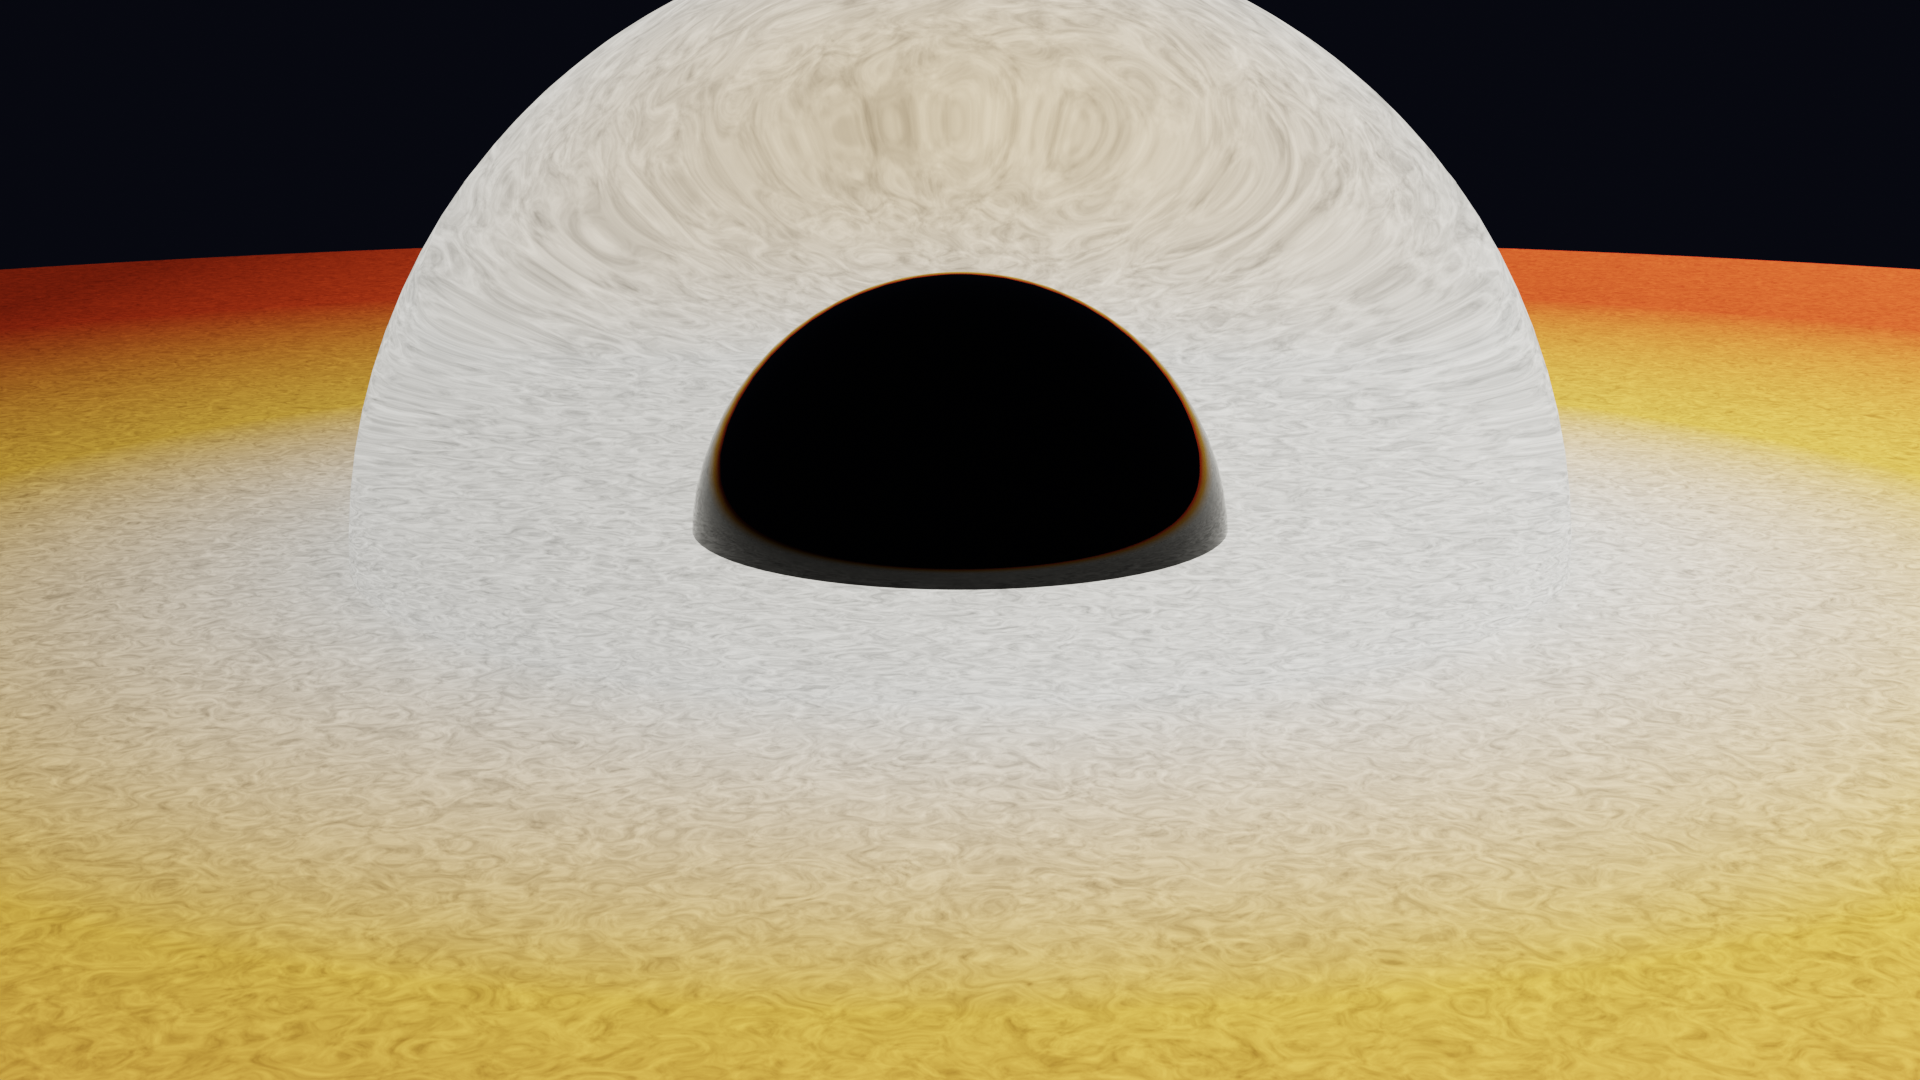

In [8]:
# Render frame 2000 (Act 2: The Accretion Storm with Doppler beaming) at 128 samples
!blender -b -P build_scene.py -- --render-frame 2000 --output /content/test_preview.png --samples 128

# Display rendered beauty image directly in the notebook
from IPython.display import Image, display
display(Image('/content/test_preview.png', width=960))

## 5. Production Batch Render (Cycles GPU 256–512 Samples to Google Drive)

In [ ]:
# You can render by Act or custom frame ranges:
# --act 1 : The Approach (Frames 1 - 1440)
# --act 2 : The Accretion Storm (Frames 1441 - 3600)
# --act 3 : The Plunge to the Photon Sphere (Frames 3601 - 5400)
# --act 4 : The Singularity & Beyond (Frames 5401 - 6480)
# Note: Automatically skips any frames that are already saved in your Google Drive!

!blender -b -P colab/render_colab.py -- --act 1 --samples 256

Blender 4.2.0 (hash a51f293548ad built 2024-07-16 06:27:02)
  COLAB GPU BLACK HOLE RENDERER INITIALIZED
  Frame Range : 1 -> 1440 (Total: 1440 frames)
  Samples     : 256 (Cycles)
  Output Path : /content/drive/MyDrive/blackhole_film/frames
=== Initializing Black Hole Scene Assembly ===
HIP hipInit: Invalid device
=== Scene Assembly Complete. Total Frames: 6480 ===
Fra:1 Mem:12.28M (Peak 12.28M) | Time:00:00.32 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | EventHorizon_Sphere
Fra:1 Mem:12.33M (Peak 12.33M) | Time:00:00.32 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | GravitationalLens_Sphere
Fra:1 Mem:13.16M (Peak 13.16M) | Time:00:00.32 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | PhotonRing_Torus
Fra:1 Mem:13.37M (Peak 13.37M) | Time:00:00.32 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer | Synchronizing object | AccretionDisk_Mesh
Fra:1 Mem:13.43M (Peak 13.43M) | Time:00:00.32 | Mem:0.00M, Peak:0.00M | Scene, ViewLayer |

## 6. Assemble Final Master Film (Frames + Audio via FFmpeg)

In [ ]:
# Combine rendered frames from Google Drive with the master audio track
!chmod +x assemble_film.sh
!./assemble_film.sh /content/drive/MyDrive/blackhole_film/frames audio/ambient_score_foley.wav /content/drive/MyDrive/blackhole_film/The_Anatomy_of_a_Black_Hole_Master.mp4

print('✓ Master film saved to your Google Drive: /content/drive/MyDrive/blackhole_film/The_Anatomy_of_a_Black_Hole_Master.mp4')